# Vector Similarity Search: A Practical Guide
# ============================================

This notebook demonstrates how to use vector representations to find similar items.
We'll cover:
1. Vector basics and distance metrics
2. Text similarity using embeddings
3. Efficient similarity search with libraries
4. Real-world applications

## Part 1: Understanding Vector Similarity

First, let's install required packages (uncomment if needed):

**NumPy (numpy):** The core library for scientific computing in Python, providing support for large multi-dimensional arrays, matrices, and high-level mathematical functions.

**Scikit-learn (sklearn):** A machine learning library for predictive data analysis, featuring algorithms like regression, classification, and clustering, built on NumPy, SciPy, and Matplotlib.

**Sentence-transformers (sentence-transformers):** A framework based on Transformers (like BERT) to compute dense vector representations (embeddings) for sentences or paragraphs, capturing semantic meaning.

**FAISS-cpu (faiss-cpu):** A library developed by Meta for efficient similarity search and clustering of dense vectors, designed for fast retrieval in large datasets. 

In [9]:
!pip install numpy scikit-learn sentence-transformers faiss-cpu

In [10]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 17.7 MB/s  0:00:000.0 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 20.7 MB/s  0:00:004.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib] 4/5 [matplotlib]


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import matplotlib.pyplot as plt

### 1.1 Basic Vector Operations

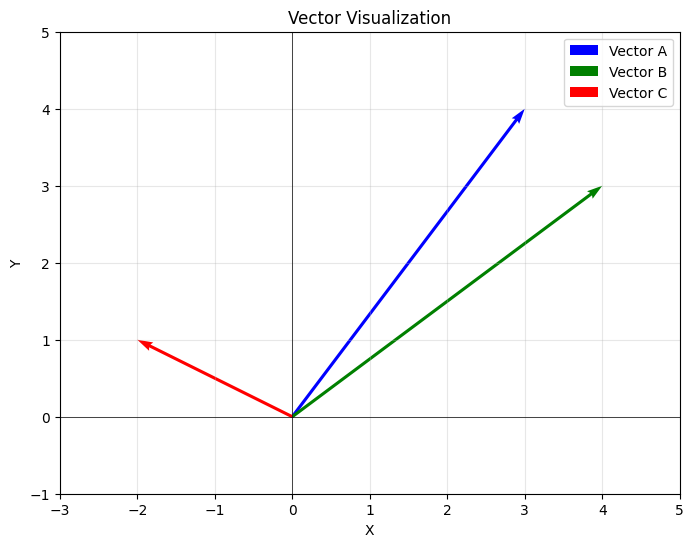

In [16]:
# Create some simple 2D vectors
vector_a = np.array([3, 4])
vector_b = np.array([4, 3])
vector_c = np.array([-2, 1])

# Visualize vectors
plt.figure(figsize=(8, 6))
plt.quiver(0, 0, vector_a[0], vector_a[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label='Vector A')
plt.quiver(0, 0, vector_b[0], vector_b[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.005, label='Vector B')
plt.quiver(0, 0, vector_c[0], vector_c[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.005, label='Vector C')
plt.xlim(-3, 5)
plt.ylim(-1, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Vector Visualization')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

### 1.2 Distance Metrics

In [17]:
def calculate_similarities(v1, v2):
    """Calculate different similarity/distance metrics between two vectors"""
    
    # Euclidean Distance (L2 norm)
    euclidean = np.linalg.norm(v1 - v2)
    
    # Cosine Similarity (measures angle between vectors)
    cosine_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    
    # Manhattan Distance (L1 norm)
    manhattan = np.sum(np.abs(v1 - v2))
    
    return {
        'euclidean_distance': euclidean,
        'cosine_similarity': cosine_sim,
        'manhattan_distance': manhattan
    }

# Compare vectors
print("Comparing Vector A and Vector B (similar direction):")
print(calculate_similarities(vector_a, vector_b))
print("\nComparing Vector A and Vector C (different direction):")
print(calculate_similarities(vector_a, vector_c))

Comparing Vector A and Vector B (similar direction):
{'euclidean_distance': np.float64(1.4142135623730951), 'cosine_similarity': np.float64(0.96), 'manhattan_distance': np.int64(2)}

Comparing Vector A and Vector C (different direction):
{'euclidean_distance': np.float64(5.830951894845301), 'cosine_similarity': np.float64(-0.17888543819998318), 'manhattan_distance': np.int64(8)}


### Euclidean Distance (L2 Norm) 
Often called the "as-the-crow-flies" distance, it is the most intuitive metric, representing the shortest possible straight line between two points. 

* **How it works:** It uses the Pythagorean theorem, calculating the square root of the sum of squared differences between coordinates.
* **Key Characteristic:** It is highly sensitive to the magnitude and scale of data features.
* **Best Use Cases:** Dense, continuous numerical data (e.g., finding the nearest physical location or clustering similar images). 

### Manhattan Distance (L1 Norm)
Also known as "Taxicab" or "City Block" distance, it represents the distance between two points if you could only move along a grid at right angles. 

* **How it works:** It calculates the sum of the absolute differences of their coordinates.
* **Key Characteristic:** It is generally preferred over Euclidean distance for high-dimensional data because it is less sensitive to outliers.
* **Best Use Cases:** Grid-constrained paths (like a GPS in a city), discrete attributes, or high-dimensional datasets where Euclidean distance becomes less reliable.

### Cosine Similarity
Unlike the others, this is not a traditional distance measure. It measures the angle between two vectors rather than the physical space between them. 

* **How it works:** It calculates the cosine of the angle between two vectors. A similarity of 1 means they point in the same direction; 0 means they are perpendicular.
* **Key Characteristic:** It ignores the magnitude (size) of the vectors and only cares about their orientation.
* **Best Use Cases:** Text mining, recommendation systems, and high-dimensional embeddings where you care if two items are "about the same thing" regardless of their length (e.g., comparing a short news summary to a long article).

**Key Insight:** Cosine similarity focuses on direction (angle), while Euclidean 
distance considers both direction and magnitude. For text similarity, cosine 
similarity is often preferred because document length doesn't matter as much 
as content similarity.

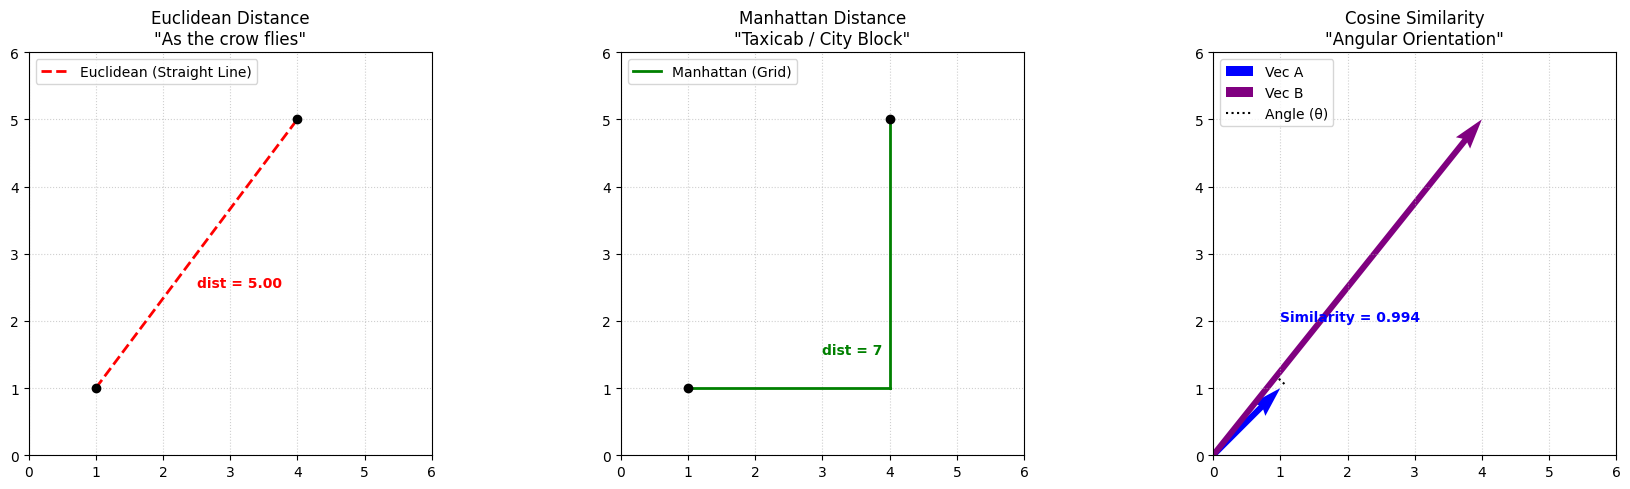

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define two points for comparison
p1 = np.array([1, 1])
p2 = np.array([4, 5])

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. EUCLIDEAN DISTANCE (L2) ---
axs[0].plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', linewidth=2, label='Euclidean (Straight Line)')
axs[0].scatter([p1[0], p2[0]], [p1[1], p2[1]], color='black', zorder=5)
axs[0].set_title('Euclidean Distance\n"As the crow flies"')
axs[0].text(2.5, 2.5, f'dist = {np.linalg.norm(p2-p1):.2f}', color='red', fontweight='bold')

# --- 2. MANHATTAN DISTANCE (L1) ---
axs[1].plot([p1[0], p2[0]], [p1[1], p1[1]], 'g-', linewidth=2) # Horizontal
axs[1].plot([p2[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2, label='Manhattan (Grid)') # Vertical
axs[1].scatter([p1[0], p2[0]], [p1[1], p2[1]], color='black', zorder=5)
axs[1].set_title('Manhattan Distance\n"Taxicab / City Block"')
man_dist = np.sum(np.abs(p2-p1))
axs[1].text(3, 1.5, f'dist = {man_dist}', color='green', fontweight='bold')

# --- 3. COSINE SIMILARITY (Angular) ---
# Draw vectors from origin
axs[2].quiver(0, 0, p1[0], p1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.015, label='Vec A')
axs[2].quiver(0, 0, p2[0], p2[1], angles='xy', scale_units='xy', scale=1, color='purple', width=0.015, label='Vec B')
# Draw an arc to represent the angle
theta = np.linspace(np.arctan2(p1[1], p1[0]), np.arctan2(p2[1], p2[0]), 100)
r = 1.5
axs[2].plot(r*np.cos(theta), r*np.sin(theta), 'k:', label='Angle (θ)')
axs[2].set_title('Cosine Similarity\n"Angular Orientation"')
cos_sim = np.dot(p1, p2) / (np.linalg.norm(p1) * np.linalg.norm(p2))
axs[2].text(1, 2, f'Similarity = {cos_sim:.3f}', color='blue', fontweight='bold')

# Formatting for all plots
for ax in axs:
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_aspect('equal')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Part 2: Text Similarity with Word Embeddings

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "The cat sits on the mat",
    "The dog plays in the garden",
    "A cat and a dog are friends",
    "The quick brown fox jumps over the lazy dog",
    "Machine learning uses vector representations"
]

# Convert documents to vectors using TF-IDF
vectorizer = TfidfVectorizer()
doc_vectors = vectorizer.fit_transform(documents)

print("Document vectors shape:", doc_vectors.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))
print("\nSample vocabulary:", list(vectorizer.vocabulary_.items())[:10])

Document vectors shape: (5, 23)
Vocabulary size: 23

Sample vocabulary: [('the', 20), ('cat', 3), ('sits', 19), ('on', 14), ('mat', 13), ('dog', 4), ('plays', 16), ('in', 8), ('garden', 7), ('and', 0)]


### 2.1 Finding Similar Documents

In [25]:
def find_most_similar(query_idx, vectors, documents, top_k=3):
    """Find the most similar documents to a query document"""
    
    # Calculate cosine similarity between query and all documents
    query_vector = vectors[query_idx]
    similarities = cosine_similarity(query_vector, vectors).flatten()
    
    # Get top-k similar documents (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]
    
    print(f"Query: '{documents[query_idx]}'")
    print("\nMost similar documents:")
    for idx in similar_indices:
        print(f"  - Similarity: {similarities[idx]:.3f} | '{documents[idx]}'")

# Test similarity search
find_most_similar(0, doc_vectors, documents)

Query: 'The cat sits on the mat'

Most similar documents:
  - Similarity: 0.336 | 'The dog plays in the garden'
  - Similarity: 0.268 | 'The quick brown fox jumps over the lazy dog'
  - Similarity: 0.138 | 'A cat and a dog are friends'


## Part 3: Using Modern Embeddings (Sentence Transformers)

The all-MiniLM-L6-v2 model outputs embeddings with 384 dimensions. This makes it an efficient, lightweight model well-suited for tasks where speed and resource usage are a concern. 

In [12]:
from sentence_transformers import SentenceTransformer

# Load pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Example corpus
corpus = [
    "Python is a popular programming language",
    "Machine learning models require training data",
    "Neural networks are inspired by the human brain",
    "Data science involves statistics and programming",
    "Deep learning is a subset of machine learning",
    "The weather is nice today",
    "I enjoy hiking in the mountains"
]

# Generate embeddings
corpus_embeddings = model.encode(corpus)
print("Embedding shape:", corpus_embeddings.shape)
print("Each document is represented by a", corpus_embeddings.shape[1], "dimensional vector")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (7, 384)
Each document is represented by a 384 dimensional vector


### 3.1 Semantic Search Function

In [13]:
def semantic_search(query, corpus, corpus_embeddings, model, top_k=3):
    """Perform semantic search using sentence embeddings"""
    
    # Encode the query
    query_embedding = model.encode([query])
    
    # Calculate cosine similarities
    similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
    
    # Get top-k results
    top_indices = similarities.argsort()[::-1][:top_k]
    
    print(f"Query: '{query}'")
    print(f"\nTop {top_k} results:")
    for idx in top_indices:
        print(f"  Score: {similarities[idx]:.4f} | '{corpus[idx]}'")
    
    return top_indices, similarities[top_indices]

# Test semantic search
semantic_search(
    query="What is artificial intelligence?",
    corpus=corpus,
    corpus_embeddings=corpus_embeddings,
    model=model
)

Query: 'What is artificial intelligence?'

Top 3 results:
  Score: 0.4335 | 'Deep learning is a subset of machine learning'
  Score: 0.4028 | 'Neural networks are inspired by the human brain'
  Score: 0.3483 | 'Data science involves statistics and programming'


(array([4, 2, 3]), array([0.433497  , 0.40279394, 0.34831434], dtype=float32))

## Part 4: Efficient Search with FAISS

FAISS (Facebook AI Similarity Search) is an open-source software library developed by Meta (formerly Facebook) AI Research, designed to enable efficient similarity search and clustering of dense vectors. 

In [26]:
import faiss

# Create FAISS index for faster similarity search
dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)  # L2 (Euclidean) distance

# Add vectors to the index
index.add(corpus_embeddings.astype('float32'))

print(f"Index contains {index.ntotal} vectors")

Index contains 7 vectors


### 4.1 Fast Similarity Search

In [27]:
def faiss_search(query, corpus, index, model, k=3):
    """Fast similarity search using FAISS"""
    
    # Encode query
    query_vector = model.encode([query]).astype('float32')
    
    # Search the index
    distances, indices = index.search(query_vector, k)
    
    print(f"Query: '{query}'")
    print(f"\nTop {k} results:")
    for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        print(f"  Distance: {dist:.4f} | '{corpus[idx]}'")
    
    return indices[0], distances[0]

# Test FAISS search
faiss_search(
    query="learning algorithms",
    corpus=corpus,
    index=index,
    model=model
)

Query: 'learning algorithms'

Top 3 results:
  Distance: 1.1348 | 'Deep learning is a subset of machine learning'
  Distance: 1.2028 | 'Machine learning models require training data'
  Distance: 1.2314 | 'Neural networks are inspired by the human brain'


(array([4, 1, 2]), array([1.1348004, 1.2028085, 1.2314129], dtype=float32))

## Part 5: Practical Application - Building a Mini Search Engine

In [28]:
class SimpleSearchEngine:
    """A simple vector-based search engine"""
    
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)
        self.corpus = []
        self.embeddings = None
        self.index = None
    
    def add_documents(self, documents):
        """Add documents to the search engine"""
        self.corpus.extend(documents)
        
        # Generate embeddings
        new_embeddings = self.model.encode(documents)
        
        if self.embeddings is None:
            self.embeddings = new_embeddings
        else:
            self.embeddings = np.vstack([self.embeddings, new_embeddings])
        
        # Rebuild FAISS index
        dimension = self.embeddings.shape[1]
        self.index = faiss.IndexFlatL2(dimension)
        self.index.add(self.embeddings.astype('float32'))
    
    def search(self, query, k=5):
        """Search for similar documents"""
        query_vector = self.model.encode([query]).astype('float32')
        distances, indices = self.index.search(query_vector, k)
        
        results = []
        for dist, idx in zip(distances[0], indices[0]):
            results.append({
                'document': self.corpus[idx],
                'distance': float(dist),
                'similarity': 1 / (1 + dist)  # Convert distance to similarity score
            })
        
        return results

# Create and test the search engine
search_engine = SimpleSearchEngine()

# Add a knowledge base
knowledge_base = [
    "Python is a high-level programming language known for its simplicity",
    "JavaScript is primarily used for web development",
    "Machine learning algorithms learn patterns from data",
    "Neural networks consist of layers of interconnected nodes",
    "Data preprocessing is crucial for model performance",
    "Version control systems like Git help manage code changes",
    "APIs allow different software systems to communicate",
    "Cloud computing provides on-demand computing resources",
    "Databases store and organize structured data",
    "Agile methodology emphasizes iterative development"
]

search_engine.add_documents(knowledge_base)

# Perform searches
print("=" * 60)
print("SEARCH RESULTS")
print("=" * 60)

queries = [
    "How do neural networks work?",
    "What programming language should I learn?",
    "Tell me about storing data"
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("-" * 60)
    results = search_engine.search(query, k=3)
    
    for i, result in enumerate(results, 1):
        print(f"{i}. [{result['similarity']:.3f}] {result['document']}")

SEARCH RESULTS

Query: 'How do neural networks work?'
------------------------------------------------------------
1. [0.593] Neural networks consist of layers of interconnected nodes
2. [0.459] Machine learning algorithms learn patterns from data
3. [0.372] JavaScript is primarily used for web development

Query: 'What programming language should I learn?'
------------------------------------------------------------
1. [0.547] Python is a high-level programming language known for its simplicity
2. [0.448] JavaScript is primarily used for web development
3. [0.374] APIs allow different software systems to communicate

Query: 'Tell me about storing data'
------------------------------------------------------------
1. [0.550] Databases store and organize structured data
2. [0.410] Data preprocessing is crucial for model performance
3. [0.387] Machine learning algorithms learn patterns from data


## Key Takeaways

1. Vector representations enable semantic similarity search
2. Cosine similarity is ideal for text because it focuses on content, not length
3. Modern embeddings (like Sentence Transformers) capture semantic meaning
4. FAISS enables efficient similarity search at scale
5. Applications: search engines, recommendation systems, duplicate detection, Q&A systems